In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
import numpy as np
import os
import kagglehub
import missingno as msn
from IPython.display import display, HTML
import pytimetk as tk
from statsmodels.stats.outliers_influence import variance_inflation_factor
sns.set()

In [ ]:
# 1. Download the dataset
path = kagglehub.dataset_download("ankitverma2010/ecommerce-customer-churn-analysis-and-prediction")

# 2. Look for the Excel file in the downloaded path
file_path = os.path.join(path, "E Commerce Dataset.xlsx")

# 3. Load the 'E Comm' sheet (this is the raw data)
# Note: You may need to run 'pip install openpyxl' first
df = pd.read_excel(file_path, sheet_name='E Comm')


### EDA

In [4]:
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [5]:
print(f'shape: {df.shape}')
print(f'duplicates: {df.duplicated().sum()}')
print('Unique Keys:',len(df['CustomerID'].unique()))

shape: (5630, 20)
duplicates: 0
Unique Keys: 5630


In [6]:
df.isna().sum()

CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64

In [12]:
print('Nb of empty rows:',df.isna().all(axis=1).sum())

Nb of empty rows: 0


In [13]:
#questions:
# what is the data about
# when was it collected, where, how
# can we fill na
# is it imbalance

In [14]:
df.columns

Index(['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier',
       'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore',
       'MaritalStatus', 'NumberOfAddress', 'Complain',
       'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount'],
      dtype='object')

<Figure size 640x480 with 0 Axes>

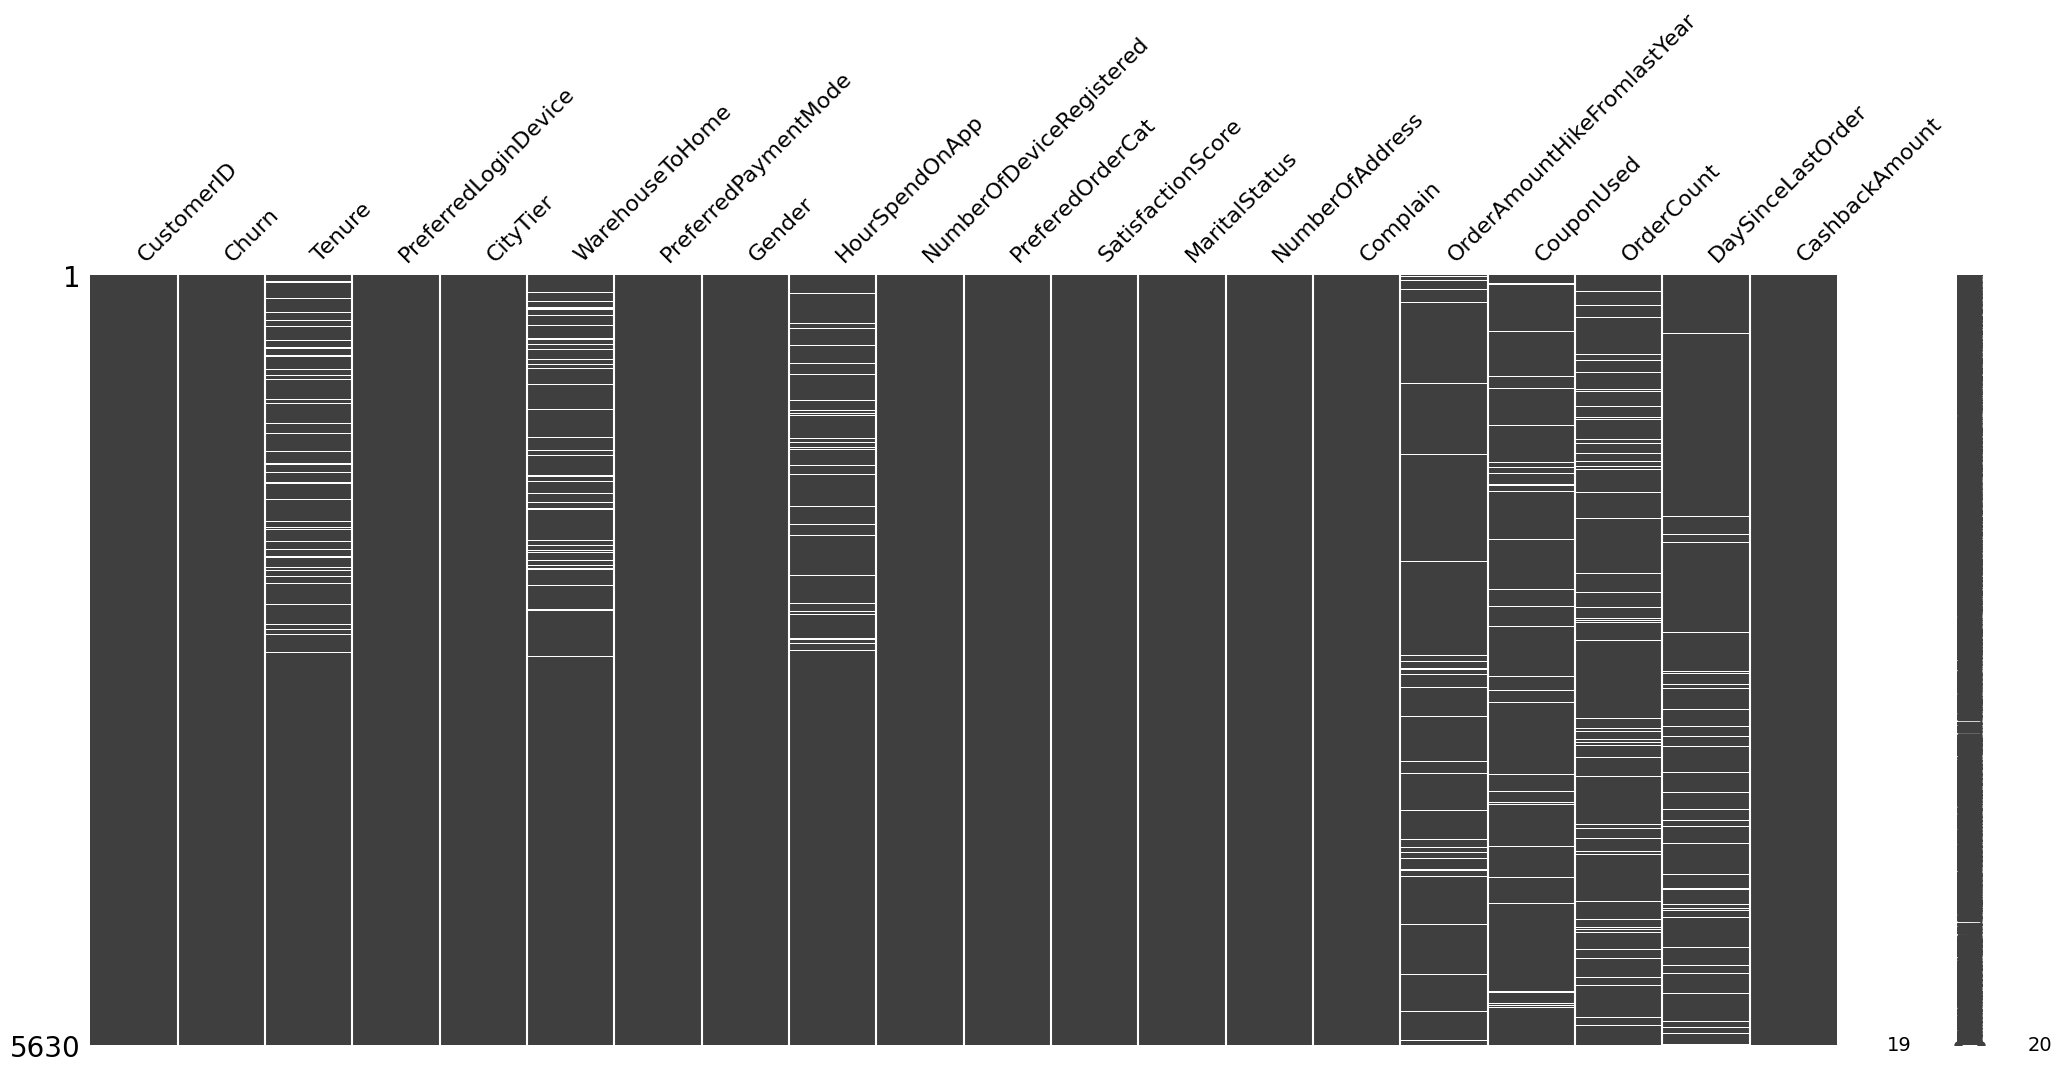

In [ ]:
plt.figure()
msn.matrix(df)
plt.show()

### 1st approach: dropping na

In [16]:
df_clean1= df.dropna()

In [ ]:
# Calculate counts and percentages
counts = df_clean1['Churn'].value_counts()
percent = df_clean1['Churn'].value_counts(normalize=True) * 100

# Create a summary DataFrame
summary_df = pd.DataFrame({
    'Count': counts,
    'Percentage (%)': percent.round(2)
})

# Display as HTML table
display(HTML("<h3>Churn Distribution Summary</h3>"))
display(HTML(summary_df.to_html(classes='table table-striped')))

,Count,Percentage (%)
Churn,,
0,3143,83.28
1,631,16.72


In [19]:
df.dtypes.value_counts()

float64    8
int64      7
object     5
Name: count, dtype: int64

In [ ]:
# Select only the specific columns you requested
target_cols = ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']
df_objects = df[target_cols]

html = """<table style='width:100%; border-collapse: collapse; font-family: sans-serif; font-size: 0.9em;'>
<tr style='background-color: #2c3e50; color: white;'>
    <th style='padding: 12px; text-align: left;'>Column</th>
    <th style='padding: 12px; text-align: center;'>Cardinality</th>
    <th style='padding: 12px; text-align: left;'>Top Values Distribution (Count & %)</th>
</tr>"""

for col in df_objects.columns:
    cardinality = df_objects[col].nunique()
    counts = df_objects[col].value_counts()
    percents = df_objects[col].value_counts(normalize=True) * 100
    
    # Using <br> to ensure each category has its own row in the right column
    dist_items = [f"<b>{k}</b>: {v} ({percents[k]:.1f}%)" for k, v in counts.items()]
    dist_str = "<div style='max-height: 200px; overflow-y: auto;'>" + "<br>".join(dist_items) + "</div>"
    
    html += f"<tr style='border-bottom: 1px solid #eee;'>"
    html += f"<td style='padding: 10px; font-weight: bold;'>{col}</td>"
    html += f"<td style='padding: 10px; text-align: center;'>{cardinality}</td>"
    html += f"<td style='padding: 10px;'>{dist_str}</td></tr>"

html += "</table>"
display(HTML(html))

Column,Cardinality,Top Values Distribution (Count & %)
PreferredLoginDevice,3,Mobile Phone: 2765 (49.1%)Computer: 1634 (29.0%)Phone: 1231 (21.9%)
PreferredPaymentMode,7,Debit Card: 2314 (41.1%)Credit Card: 1501 (26.7%)E wallet: 614 (10.9%)UPI: 414 (7.4%)COD: 365 (6.5%)CC: 273 (4.8%)Cash on Delivery: 149 (2.6%)
Gender,2,Male: 3384 (60.1%)Female: 2246 (39.9%)
PreferedOrderCat,6,Laptop & Accessory: 2050 (36.4%)Mobile Phone: 1271 (22.6%)Fashion: 826 (14.7%)Mobile: 809 (14.4%)Grocery: 410 (7.3%)Others: 264 (4.7%)
MaritalStatus,3,Married: 2986 (53.0%)Single: 1796 (31.9%)Divorced: 848 (15.1%)


In [ ]:
# phone & mobile phone merge
#-------------------------------
# debit card / (E wallet, UPI)
# credit card / (cc)
# COD / Cash on delivery
#-------------------------------
# mobile phone /mobile
# grocery / others

In [27]:
df_clean1.columns

Index(['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier',
       'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore',
       'MaritalStatus', 'NumberOfAddress', 'Complain',
       'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount'],
      dtype='object')

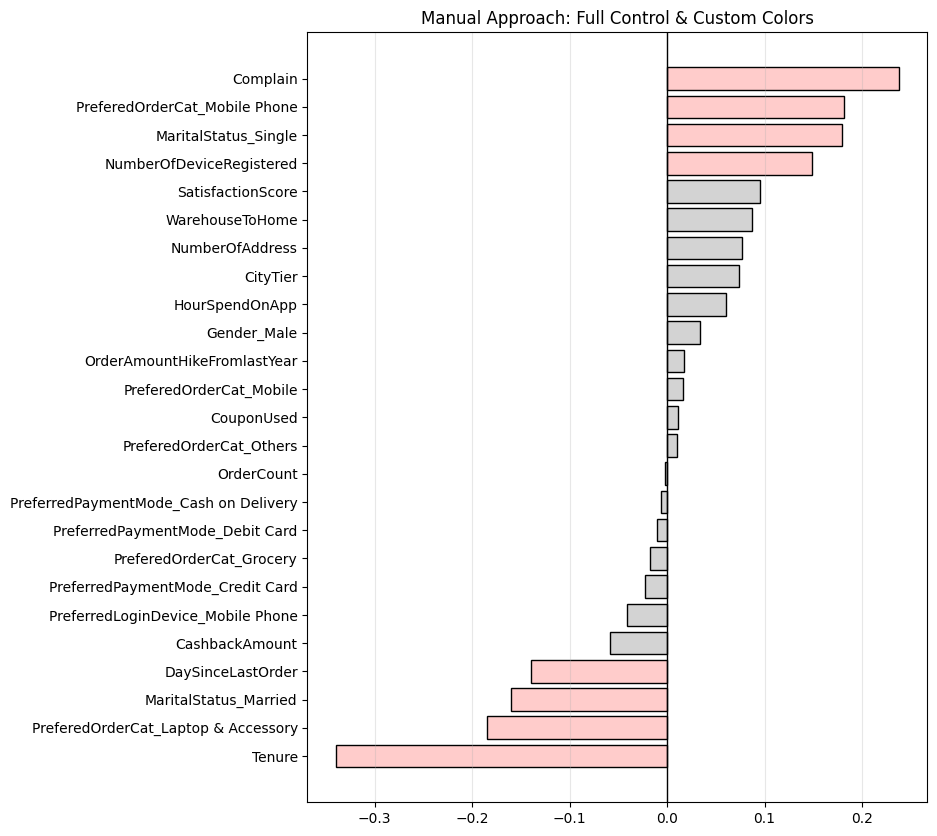

Generating pytimetk Correlation Funnel...


In [ ]:
# --- 1. PREP DATA ---
# Drop ID and handle the 'Churn' target
df_for_corr = df_clean1.drop(columns=['CustomerID'])

# --- 2. THE MANUAL APPROACH (LEFT-STYLE LOGIC) ---
# We manually encode and plot to keep total control over colors/thresholds
df_encoded = pd.get_dummies(df_for_corr, drop_first=True)
corrs = df_encoded.corr()['Churn'].sort_values(ascending=True).drop('Churn')
colors = ['#ffcccb' if abs(val) > 0.1 else '#d3d3d3' for val in corrs.values]

plt.figure(figsize=(8, 10))
plt.barh(corrs.index, corrs.values, color=colors, edgecolor='black')
plt.title("Manual Approach: Full Control & Custom Colors")
plt.axvline(0, color='black', lw=1)
plt.grid(axis='x', alpha=0.3)
plt.show()

# --- 3. THE PYTIMETK APPROACH (YOUR PROJECT LOGIC) ---
# pytimetk automates the binarization and correlation calculation
print("Generating pytimetk Correlation Funnel...")

# Note: Ensure 'Churn' is the target. pytimetk usually appends '__1' or '__Yes' 
# to the binarized target name depending on its value.
df_correlated = df_for_corr.binarize().correlate(target="Churn__1")

# This creates its own Plotly/Matplotlib interactive chart
df_correlated.plot_correlation_funnel(title="pytimetk Approach: Automated Binarization")

In [ ]:
def calculate_iv(df, feature, target):
    # Binning numerical features into 5 quantiles
    if df[feature].dtype != 'object':
        df[feature] = pd.qcut(df[feature], q=5, duplicates='drop').astype(str)
    
    lst = []
    for val in df[feature].unique():
        lst.append({
            'Value': val,
            'All': df[df[feature] == val].count()[feature],
            'Good': df[(df[feature] == val) & (df[target] == 0)].count()[feature],
            'Bad': df[(df[feature] == val) & (df[target] == 1)].count()[feature]
        })
    
    data = pd.DataFrame(lst)
    data['Dist_Good'] = data['Good'] / data['Good'].sum()
    data['Dist_Bad'] = data['Bad'] / data['Bad'].sum()
    # Adding small epsilon to avoid division by zero
    data['WoE'] = np.log((data['Dist_Good'] + 0.0001) / (data['Dist_Bad'] + 0.0001))
    data['IV'] = (data['Dist_Good'] - data['Dist_Bad']) * data['WoE']
    return data['IV'].replace([np.inf, -np.inf], 0).sum()

iv_results = []
for col in df_clean1.drop(columns=['CustomerID', 'Churn']).columns:
    iv_results.append({'Column': col, 'IV': calculate_iv(df_clean1.copy(), col, 'Churn')})

iv_df = pd.DataFrame(iv_results).sort_values(by='IV', ascending=False)

def color_iv(val):
    if val >= 0.1: color = '#e2f0d9' # Light milky green
    elif val >= 0.02: color = '#fff2cc' # Light yellow
    else: color = '#f8d7da' # Light red
    return f'background-color: {color}; color: black;'

display(HTML("<h3>Information Value (IV) Rankings</h3>"))
display(iv_df.style.applymap(color_iv, subset=['IV']))

,Column,IV
0,Tenure,1.813079
8,PreferedOrderCat,0.286093
10,MaritalStatus,0.233354
16,DaySinceLastOrder,0.176302
7,NumberOfDeviceRegistered,0.156561
17,CashbackAmount,0.100917
11,NumberOfAddress,0.085716
3,WarehouseToHome,0.064108
9,SatisfactionScore,0.051814
6,HourSpendOnApp,0.037243


In [38]:
#'Gender','CityTier','CouponUsed','OrderAmountHikeFromlastYear'

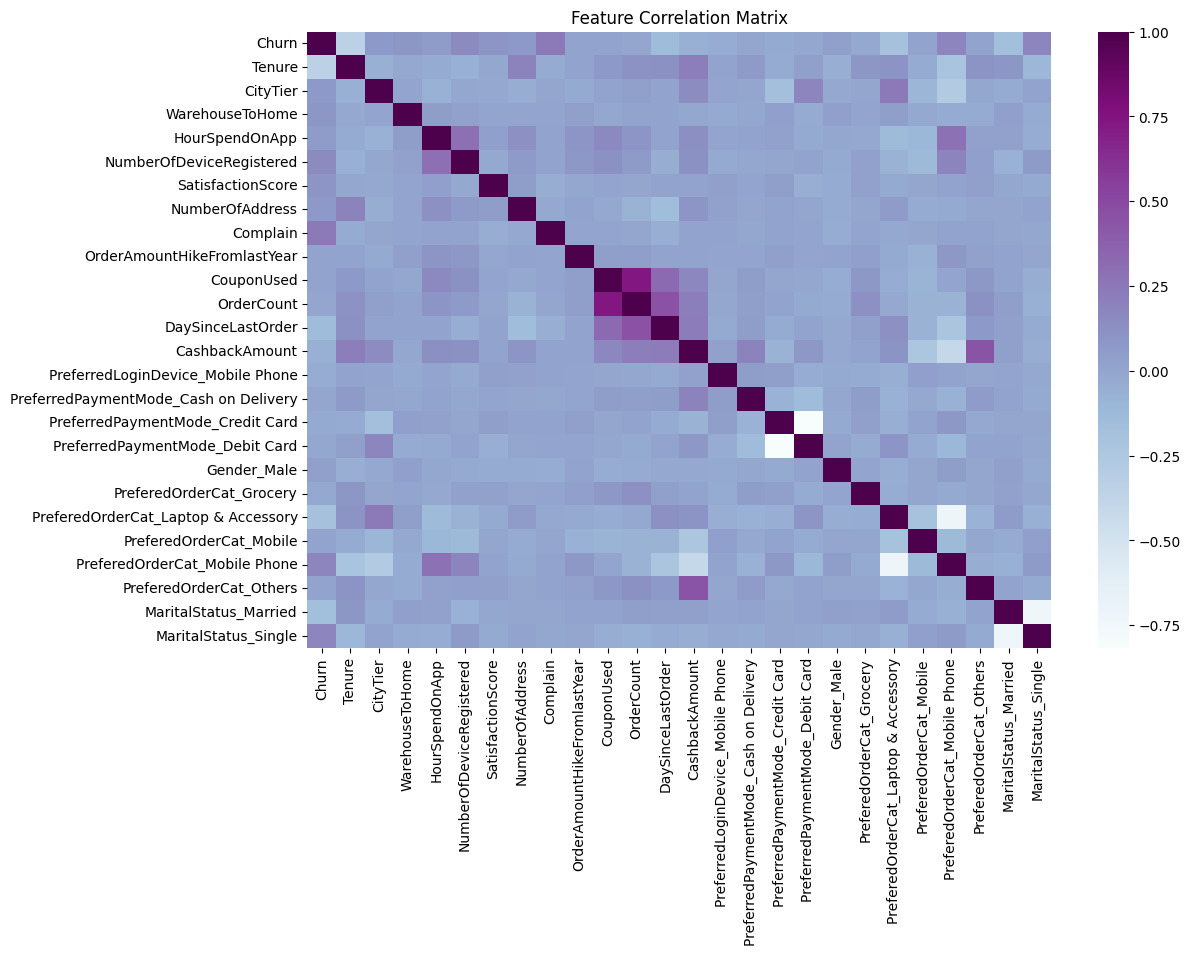

,V1,V2,Corr
271,CouponUsed,OrderCount,0.73247


In [ ]:
# Encode for correlation
df_corr_ready = pd.get_dummies(df_clean1.drop(columns=['CustomerID']), drop_first=True)
corr_matrix = df_corr_ready.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap='BuPu', annot=False)
plt.title("Feature Correlation Matrix")
plt.show()

# Critical Insights Table
high_corr = corr_matrix.unstack().reset_index()
high_corr.columns = ['V1', 'V2', 'Corr']
high_corr = high_corr[(high_corr['Corr'] > 0.7) & (high_corr['V1'] != high_corr['V2'])].drop_duplicates(subset=['Corr'])

display(HTML("<h3>Critical Insights: High Multi-collinearity</h3>"))
display(high_corr)

In [ ]:
# 1. Prepare numerical data
numeric_cols = df_clean1.select_dtypes(include=[np.number]).drop(columns=['CustomerID', 'Churn']).dropna()

# 2. Calculate VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = numeric_cols.columns
vif_data["VIF"] = [variance_inflation_factor(numeric_cols.values, i) for i in range(len(numeric_cols.columns))]

# 3. Sort the DataFrame FIRST
vif_data = vif_data.sort_values(by="VIF", ascending=False)

# 4. Styling logic with black text for all
def color_vif(val):
    color = '#f8d7da' if val > 5 else '#ffffff' # Light red if > 5, else white
    return f'background-color: {color}; color: black;'

display(HTML("<h3>VIF Table (Redundancy Check)</h3>"))
display(vif_data.style.applymap(color_vif, subset=['VIF']))

,Feature,VIF
12,CashbackAmount,36.334255
3,HourSpendOnApp,19.809198
8,OrderAmountHikeFromlastYear,16.654032
4,NumberOfDeviceRegistered,15.557459
10,OrderCount,5.751401
5,SatisfactionScore,5.586796
9,CouponUsed,4.541676
1,CityTier,4.428891
2,WarehouseToHome,4.255943
6,NumberOfAddress,4.117246


In [ ]:
#'Gender','CityTier','CouponUsed','OrderAmountHikeFromlastYear'
df_clean1= df_clean1.drop(['Gender','CityTier','CouponUsed','OrderAmountHikeFromlastYear','CashbackAmount','CustomerID'], axis= 1)

In [43]:
# 1. Prepare numerical data (Excluding ID and Target)
numeric_cols = df_clean1.select_dtypes(include=[np.number]).drop(columns=['CustomerID', 'Churn'], errors='ignore').dropna()

# 2. Calculate VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = numeric_cols.columns
vif_data["VIF"] = [variance_inflation_factor(numeric_cols.values, i) for i in range(len(numeric_cols.columns))]

# 3. Sort the DataFrame FIRST
vif_data = vif_data.sort_values(by="VIF", ascending=False)

# 4. Styling logic
def color_vif(val):
    color = '#f8d7da' if val > 5 else '#ffffff' 
    return f'background-color: {color}; color: black;'

display(HTML("<h3>VIF Table (Redundancy Check)</h3>"))
display(vif_data.style.applymap(color_vif, subset=['VIF']))

,Feature,VIF
2,HourSpendOnApp,15.833200
3,NumberOfDeviceRegistered,12.818845
4,SatisfactionScore,5.180610
1,WarehouseToHome,4.065936
5,NumberOfAddress,3.995114
8,DaySinceLastOrder,3.518945
7,OrderCount,2.991823
0,Tenure,2.415014
6,Complain,1.383049


In [48]:
df_clean1.describe().round(2)

,CustomerID,Churn,Tenure,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderCount,DaySinceLastOrder
count,3774.00,3774.00,3774.00,3774.00,3774.00,3774.00,3774.00,3774.00,3774.00,3774.00,3774.00
mean,53017.99,0.17,8.78,15.74,2.98,3.75,3.06,4.22,0.28,2.83,4.53
std,1608.98,0.37,7.68,8.59,0.72,1.03,1.39,2.56,0.45,2.47,3.37
min,50001.00,0.00,0.00,5.00,0.00,1.00,1.00,1.00,0.00,1.00,0.00
25%,51656.25,0.00,1.00,9.00,2.00,3.00,2.00,2.00,0.00,1.00,2.00
50%,53160.50,0.00,8.00,14.00,3.00,4.00,3.00,3.00,0.00,2.00,3.00
75%,54394.50,0.00,13.00,21.00,3.00,4.00,4.00,6.00,1.00,3.00,7.00
max,55630.00,1.00,51.00,127.00,5.00,6.00,5.00,22.00,1.00,16.00,46.00


In [51]:
# suspecious: NumberOfAddress,OrderCount,DaySinceLastOrder,Tenure,WarehouseToHome

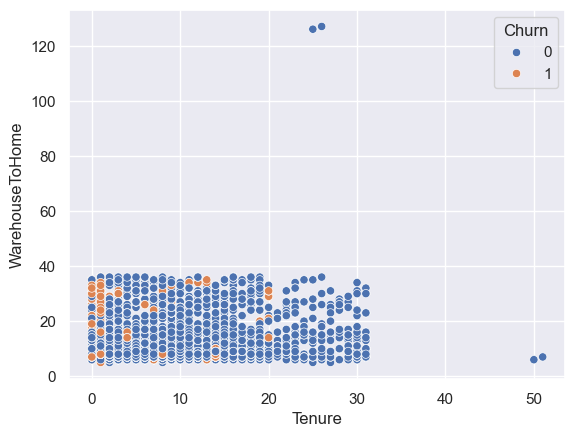

In [52]:
plt.figure()
sns.scatterplot(data= df_clean1, x='Tenure', y= 'WarehouseToHome', hue='Churn')
plt.show()

In [ ]:
# clip tenure >31 to 31,
# clip WarehouseToHome>36 to 36
df_clean1[df_clean1['WarehouseToHome']>=36]

,CustomerID,Churn,Tenure,PreferredLoginDevice,WarehouseToHome,PreferredPaymentMode,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderCount,DaySinceLastOrder
1309,51310,0,25.0,Computer,126.0,Debit Card,2.0,3,Mobile,1,Married,3,0,1.0,0.0
2889,52890,0,12.0,Mobile Phone,36.0,COD,3.0,4,Laptop & Accessory,2,Divorced,5,0,2.0,8.0
2894,52895,1,2.0,Mobile Phone,36.0,Credit Card,4.0,4,Laptop & Accessory,5,Divorced,9,1,2.0,1.0
2949,52950,1,1.0,Computer,36.0,Credit Card,4.0,5,Mobile Phone,4,Single,2,0,2.0,5.0
3099,53100,0,16.0,Computer,36.0,Debit Card,4.0,4,Laptop & Accessory,3,Married,4,0,2.0,3.0
3150,53151,0,1.0,Mobile Phone,36.0,Credit Card,3.0,4,Laptop & Accessory,3,Married,7,0,2.0,1.0
3294,53295,0,16.0,Mobile Phone,36.0,Debit Card,4.0,4,Laptop & Accessory,4,Divorced,3,0,8.0,9.0
3438,53439,1,1.0,Computer,36.0,Credit Card,4.0,6,Laptop & Accessory,5,Single,10,0,3.0,3.0
3446,53447,0,6.0,Computer,36.0,Credit Card,4.0,4,Mobile Phone,3,Single,11,0,8.0,8.0
3482,53483,1,1.0,Computer,36.0,Credit Card,3.0,5,Laptop & Accessory,3,Single,3,0,4.0,9.0


In [44]:
df_clean1.columns

Index(['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice',
       'WarehouseToHome', 'PreferredPaymentMode', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore',
       'MaritalStatus', 'NumberOfAddress', 'Complain', 'OrderCount',
       'DaySinceLastOrder'],
      dtype='object')

### Feature Engineering

In [ ]:
df_clean2= df.drop(['Gender','CityTier','CouponUsed','OrderAmountHikeFromlastYear','CashbackAmount','CustomerID'], axis= 1)

In [45]:
def drop_redundant_features(df):
    """Drops the specified columns to prepare for model training."""
    cols_to_drop = [
        'Gender', 'CityTier', 'CouponUsed', 
        'OrderAmountHikeFromlastYear', 'CashbackAmount', 'CustomerID'
    ]
    # errors='ignore' ensures the code doesn't crash if columns are already gone
    return df.drop(columns=cols_to_drop, errors='ignore')

# Application
df_clean2 = drop_redundant_features(df)

### Preprocessing

In [46]:
from sklearn.preprocessing import FunctionTransformer

def consolidate_labels(df):
    df = df.copy()
    
    # 1. PreferredLoginDevice: Merge mobile types
    df['PreferredLoginDevice'] = df['PreferredLoginDevice'].replace(['Phone', 'Mobile Phone'], 'Phone')
    
    # 2. PreferredPaymentMode: Group by payment architecture
    df['PreferredPaymentMode'] = df['PreferredPaymentMode'].replace({
        'E wallet': 'Debit Card', 'UPI': 'Debit Card', 'Debit Card': 'Debit Card',
        'CC': 'Credit Card', 'Credit Card': 'Credit Card',
        'Cash on Delivery': 'COD', 'COD': 'COD'
    })
    
    # 3. PreferedOrderCat: Group by product category
    df['PreferedOrderCat'] = df['PreferedOrderCat'].replace({
        'Mobile Phone': 'Phone', 'Mobile': 'Phone',
        'Grocery': 'Others', 'Others': 'Others'
    })
    
    return df

# Create the transformer
label_merger = FunctionTransformer(consolidate_labels)

# Apply it
df_preprocessed = label_merger.transform(df_clean2)